# Mixed Effects Model Analysis

Statistical testing of condition differences using linear mixed effects models.

**Model Structure:**
- Fixed effect: `condition`
- Random effects: `ID` (animal), `stub` (measurement location)
- Dependent variables: diameter (area), diameter (profiles), porosity, density

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.regression.mixed_linear_model import MixedLM
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("WARNING: statsmodels not available. Install with: pip install statsmodels")

sns.set_theme(style="whitegrid")
print(f"statsmodels available: {HAS_STATSMODELS}")

statsmodels available: True


In [2]:
# Load data from same sources as main visualization notebook
repo_root = Path("C:/Users/sthui4072/Github/fenestrations")
data_path = repo_root / "roi_data.pickle"
metafile_path = repo_root / "fenestrations_metafile.xlsx"
metrics_file = repo_root / "stub_profile_metrics_major_minor.xlsx"
union_summary_file = repo_root / "union_masks" / "union_mask_summary.csv"

for p in [data_path, metafile_path, metrics_file, union_summary_file]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

data = pd.read_pickle(data_path)
rois_df = data["rois"].copy()
summary_df = data["summary"].copy()
metadata = pd.read_excel(metafile_path)
metrics_df = pd.read_excel(metrics_file)
union_area_df = pd.read_csv(union_summary_file)

def _stub_key(value):
    if pd.isna(value):
        return None
    return "".join(ch for ch in str(value).upper() if ch.isalnum())

# Add condition to metrics_df if needed
if "condition" not in metrics_df.columns:
    meta_lookup = (
        metadata[["stub", "condition"]]
        .dropna(subset=["stub", "condition"])
        .assign(_stub_key=lambda d: d["stub"].map(_stub_key))
        .drop_duplicates(subset=["_stub_key"], keep="first")
        [["_stub_key", "condition"]]
    )
    metrics_df = metrics_df.assign(_stub_key=metrics_df["stub"].map(_stub_key)).merge(
        meta_lookup,
        on="_stub_key",
        how="left"
    )

print(f"Loaded {len(rois_df)} ROI records")
print(f"Loaded {len(metrics_df)} metric records")
print(f"Loaded {len(union_area_df)} union mask records")

Loaded 234865 ROI records
Loaded 548 metric records
Loaded 548 union mask records


In [3]:
def extract_animal_id(stub):
    """
    Extract animal ID from stub string.
    Stub format: "FAS_XX_ME_YY" -> Animal ID: "FAS_XX"
    """
    if pd.isna(stub):
        return None
    stub_str = str(stub).upper()
    parts = stub_str.split('_')
    # Assuming format is [ANIMAL_PREFIX]_[NUMBER]_ME_[EVENT]
    # Extract [ANIMAL_PREFIX]_[NUMBER]
    if len(parts) >= 3 and 'ME' in parts:
        me_idx = parts.index('ME')
        animal_id = '_'.join(parts[:me_idx])
        return animal_id
    return stub_str

# Test the extraction
sample_stubs = rois_df['stub'].dropna().unique()[:3]
print("Sample stub -> animal_id mappings:")
for stub in sample_stubs:
    aid = extract_animal_id(stub)
    print(f"  {stub} -> {aid}")

# Extract animal IDs
rois_df['animal_id'] = rois_df['stub'].map(extract_animal_id)
metrics_df['animal_id'] = metrics_df['stub'].map(extract_animal_id)
union_area_df['animal_id'] = union_area_df['stub'].map(extract_animal_id)

print(f"\nExtracted {rois_df['animal_id'].nunique()} unique animal IDs")
print(f"Unique animal IDs: {sorted(rois_df['animal_id'].dropna().unique())}")

Sample stub -> animal_id mappings:
  FAS15_ME_04 -> FAS15
  FAS15_ME_05 -> FAS15
  FAS15_ME_07 -> FAS15

Extracted 24 unique animal IDs
Unique animal IDs: ['FAS15', 'FAS16', 'FAS19', 'FAS20', 'FAS23', 'FAS24', 'FAS4', 'FAS6', 'PR1', 'PR10', 'PR11', 'PR12', 'PR13', 'PR14', 'PR16', 'PR17', 'PR20', 'PR21', 'PR22', 'PR24', 'PR3', 'PR5', 'PR6', 'PR9']


In [4]:
# Prepare data for diameter from area analysis
diameter_area_df = rois_df[['animal_id', 'stub', 'condition', 'diameter_area']].dropna().copy()
diameter_area_df = diameter_area_df[diameter_area_df['diameter_area'] > 0]

print(f"Diameter (area) analysis:")
print(f"  Total observations: {len(diameter_area_df)}")
print(f"  Unique animals: {diameter_area_df['animal_id'].nunique()}")
print(f"  Unique stubs: {diameter_area_df['stub'].nunique()}")
print(f"  Conditions: {sorted(diameter_area_df['condition'].unique())}")
print(f"\nSummary by condition:")
print(diameter_area_df.groupby('condition')['diameter_area'].describe())

Diameter (area) analysis:
  Total observations: 234865
  Unique animals: 24
  Unique stubs: 548
  Conditions: ['control', 'fasted', 'restricted']

Summary by condition:
               count       mean       std        min        25%        50%  \
condition                                                                    
control      59363.0  46.046521  8.248572  22.032331  41.218716  45.702334   
fasted       65275.0  47.598941  9.629633  22.044272  41.970839  46.297397   
restricted  110227.0  46.786102  7.757855  21.996506  42.211047  46.541125   

                  75%        max  
condition                         
control     50.138571  97.292138  
fasted      52.124970  97.255333  
restricted  51.081443  97.123185  


In [10]:
# Prepare data for diameter from profiles analysis
method_specs = [
    ("p2p", "major_p2p_nm", "minor_p2p_nm"),
    ("fwhm", "major_fwhm_nm", "minor_fwhm_nm"),
    ("derivative", "major_derivative_nm", "minor_derivative_nm"),
]

profile_rows = []
for method, major_col, minor_col in method_specs:
    tmp = metrics_df[["animal_id", "stub", "condition", major_col, minor_col]].dropna().copy()
    tmp = tmp[(tmp[major_col] > 0) & (tmp[minor_col] > 0)]
    tmp["diameter_nm"] = np.sqrt(tmp[major_col] * tmp[minor_col])
    tmp["method"] = method
    profile_rows.append(tmp[["animal_id", "stub", "condition", "method", "diameter_nm"]])

diameter_profile_df = pd.concat(profile_rows, ignore_index=True)

print(f"Diameter (profile) analysis:")
print(f"  Total observations: {len(diameter_profile_df)}")
print(f"  Unique animals: {diameter_profile_df['animal_id'].nunique()}")
print(f"  Unique stubs: {diameter_profile_df['stub'].nunique()}")
print(f"  Methods: {sorted(diameter_profile_df['method'].unique())}")
print(f"  Conditions: {sorted(diameter_profile_df['condition'].unique())}")
print(f"\nSummary by method and condition:")
print(diameter_profile_df.groupby(['method', 'condition'])['diameter_nm'].describe())

Diameter (profile) analysis:
  Total observations: 1644
  Unique animals: 24
  Unique stubs: 548
  Methods: ['derivative', 'fwhm', 'p2p']
  Conditions: ['control', 'fasted', 'restricted']

Summary by method and condition:
                       count       mean        std        min        25%  \
method     condition                                                       
derivative control     137.0  52.109278   2.733722  45.385463  49.958985   
           fasted      138.0  51.511566   3.273300  45.176833  49.250099   
           restricted  273.0  53.243934   3.892033  46.057505  50.829395   
fwhm       control     137.0  79.106074   9.414341  61.847317  72.448942   
           fasted      138.0  84.425980  13.641490  64.009680  75.000975   
           restricted  273.0  78.309602  10.786114  56.468461  70.682952   
p2p        control     137.0  74.678497   6.156122  60.070629  71.271372   
           fasted      138.0  76.426220   9.062818  60.158337  69.576939   
           restric

In [6]:
# Prepare porosity and density metrics
# First, compute porosity metrics for each stub from union masks

# Get summary data grouped by stub to compute porosity
if "stub" in summary_df.columns:
    # Compute union coverage from union_area_df
    union_stub_group = union_area_df.groupby('stub')[['covered_area_nm2']].sum().reset_index()
    
    # Merge with ROI summary for total area
    area_data = rois_df.groupby(['animal_id', 'stub', 'condition']).size().reset_index(name='count')
    
    # Compute porosity as ratio
    porosity_df = area_data[["animal_id", "stub", "condition"]].drop_duplicates().copy()
    
    # Add union coverage
    porosity_df = porosity_df.merge(
        union_stub_group.rename(columns={'covered_area_nm2': 'union_area_nm2'}),
        on='stub',
        how='left'
    )
    
    print(f"Porosity analysis:")
    print(f"  Stub-level observations: {len(porosity_df)}")
    print(f"  Unique animals: {porosity_df['animal_id'].nunique()}")
    print(f"  Conditions: {sorted(porosity_df['condition'].unique())}")
    print(f"\nSummary by condition:")
    print(porosity_df.groupby('condition')['union_area_nm2'].describe())
else:
    print("WARNING: Creates simplified analysis for now; porosity computation may need adjustment")
    porosity_df = None

Porosity analysis:
  Stub-level observations: 548
  Unique animals: 24
  Conditions: ['control', 'fasted', 'restricted']

Summary by condition:
            count          mean           std           min           25%  \
condition                                                                   
control     137.0  4.709994e+06  1.232396e+06  3.679788e+05  3.974567e+06   
fasted      138.0  4.999880e+06  1.201093e+06  1.444942e+06  4.237675e+06   
restricted  273.0  4.662820e+06  1.424213e+06  9.400698e+05  3.738082e+06   

                     50%           75%           max  
condition                                             
control     4.806892e+06  5.534435e+06  7.584598e+06  
fasted      4.987167e+06  5.869427e+06  7.696403e+06  
restricted  4.637631e+06  5.598009e+06  9.024439e+06  


In [ ]:
if HAS_STATSMODELS:
    print("="*70)
    print("LINEAR MIXED EFFECTS MODEL: Diameter from Area")
    print("="*70)
    
    # Ensure no NaN in key columns
    model_df = diameter_area_df[['animal_id', 'stub', 'condition', 'diameter_area']].dropna().copy()
    model_df['animal_stub'] = model_df['animal_id'].astype(str) + ':' + model_df['stub'].astype(str)
    
    # Target model:
    # diameter_area ~ condition + (1 | animal_id) + (1 | animal_id:stub)
    # statsmodels equivalent uses groups + vc_formula for nested random intercepts
    model = smf.mixedlm(
        "diameter_area ~ C(condition)",
        data=model_df,
        groups=model_df["animal_id"],
        re_formula="~1",
        vc_formula={"animal_stub": "0 + C(animal_stub)"}
    )
    
    result = model.fit(reml=True)
    
    print("\nModel Summary:")
    print(result.summary())
    
    print("\nRandom Effects (animal_id):")
    print(result.random_effects)
else:
    print("statsmodels not available - skipping mixed effects modeling")

LINEAR MIXED EFFECTS MODEL: Diameter from Area

Model Summary:
                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    diameter_area
No. Observations:     234865     Method:                REML         
No. Groups:           24         Scale:                 68.5600      
Min. group size:      820        Log-Likelihood:        -829802.3981 
Max. group size:      20777      Converged:             Yes          
Mean group size:      9786.0                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  45.460    0.863 52.680 0.000 43.769 47.151
C(condition)[T.fasted]      1.603    1.219  1.315 0.189 -0.787  3.993
C(condition)[T.restricted]  1.729    1.124  1.537 0.124 -0.475  3.932
Group Var                   5.188    0.198 

In [11]:
if HAS_STATSMODELS:
    print("\n" + "="*70)
    print("LINEAR MIXED EFFECTS MODEL: Diameter from Derivative Method")
    print("="*70)
    
    # Filter to derivative method only
    model_df_profile = diameter_profile_df[
        (diameter_profile_df['method'] == 'derivative')
    ][['animal_id', 'stub', 'condition', 'diameter_nm']].dropna().copy()
    
    # Fit model with condition only
    model_profile = smf.mixedlm(
        "diameter_nm ~ C(condition)",
        data=model_df_profile,
        groups=model_df_profile["animal_id"],
        re_formula="~1"
    )
    result_profile = model_profile.fit(reml=True)
    
    print("\nModel Summary:")
    print(result_profile.summary())
else:
    print("statsmodels not available")


LINEAR MIXED EFFECTS MODEL: Diameter from Derivative Method

Model Summary:
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     diameter_nm
No. Observations:     548         Method:                 REML       
No. Groups:           24          Scale:                  10.8256    
Min. group size:      4           Log-Likelihood:         -1444.8624 
Max. group size:      47          Converged:              Yes        
Mean group size:      22.8                                           
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  52.124    0.598 87.147 0.000 50.952 53.297
C(condition)[T.fasted]     -0.796    0.826 -0.964 0.335 -2.414  0.823
C(condition)[T.restricted]  1.098    0.761  1.444 0.149 -0.393  2.589
Group Var                   1

In [12]:
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS BY CONDITION")
print("="*70)

print("\n--- Diameter from Area ---")
for condition in sorted(diameter_area_df['condition'].unique()):
    data = diameter_area_df[diameter_area_df['condition'] == condition]['diameter_area']
    print(f"\n{condition.upper()}:")
    print(f"  n = {len(data)}")
    print(f"  Mean ± SD: {data.mean():.2f} ± {data.std():.2f}")
    print(f"  Median [IQR]: {data.median():.2f} [{data.quantile(0.25):.2f} - {data.quantile(0.75):.2f}]")
    print(f"  Range: {data.min():.2f} - {data.max():.2f}")

print("\n--- Diameter from Profiles ---")
for method in sorted(diameter_profile_df['method'].unique()):
    print(f"\n{method.upper()} Method:")
    for condition in sorted(diameter_profile_df['condition'].unique()):
        data = diameter_profile_df[
            (diameter_profile_df['method'] == method) & 
            (diameter_profile_df['condition'] == condition)
        ]['diameter_nm']
        print(f"  {condition}: Mean={data.mean():.2f} ± {data.std():.2f} (n={len(data)})")


DESCRIPTIVE STATISTICS BY CONDITION

--- Diameter from Area ---

CONTROL:
  n = 59363
  Mean ± SD: 46.05 ± 8.25
  Median [IQR]: 45.70 [41.22 - 50.14]
  Range: 22.03 - 97.29

FASTED:
  n = 65275
  Mean ± SD: 47.60 ± 9.63
  Median [IQR]: 46.30 [41.97 - 52.12]
  Range: 22.04 - 97.26

RESTRICTED:
  n = 110227
  Mean ± SD: 46.79 ± 7.76
  Median [IQR]: 46.54 [42.21 - 51.08]
  Range: 22.00 - 97.12

--- Diameter from Profiles ---

DERIVATIVE Method:
  control: Mean=52.11 ± 2.73 (n=137)
  fasted: Mean=51.51 ± 3.27 (n=138)
  restricted: Mean=53.24 ± 3.89 (n=273)

FWHM Method:
  control: Mean=79.11 ± 9.41 (n=137)
  fasted: Mean=84.43 ± 13.64 (n=138)
  restricted: Mean=78.31 ± 10.79 (n=273)

P2P Method:
  control: Mean=74.68 ± 6.16 (n=137)
  fasted: Mean=76.43 ± 9.06 (n=138)
  restricted: Mean=74.04 ± 7.33 (n=273)


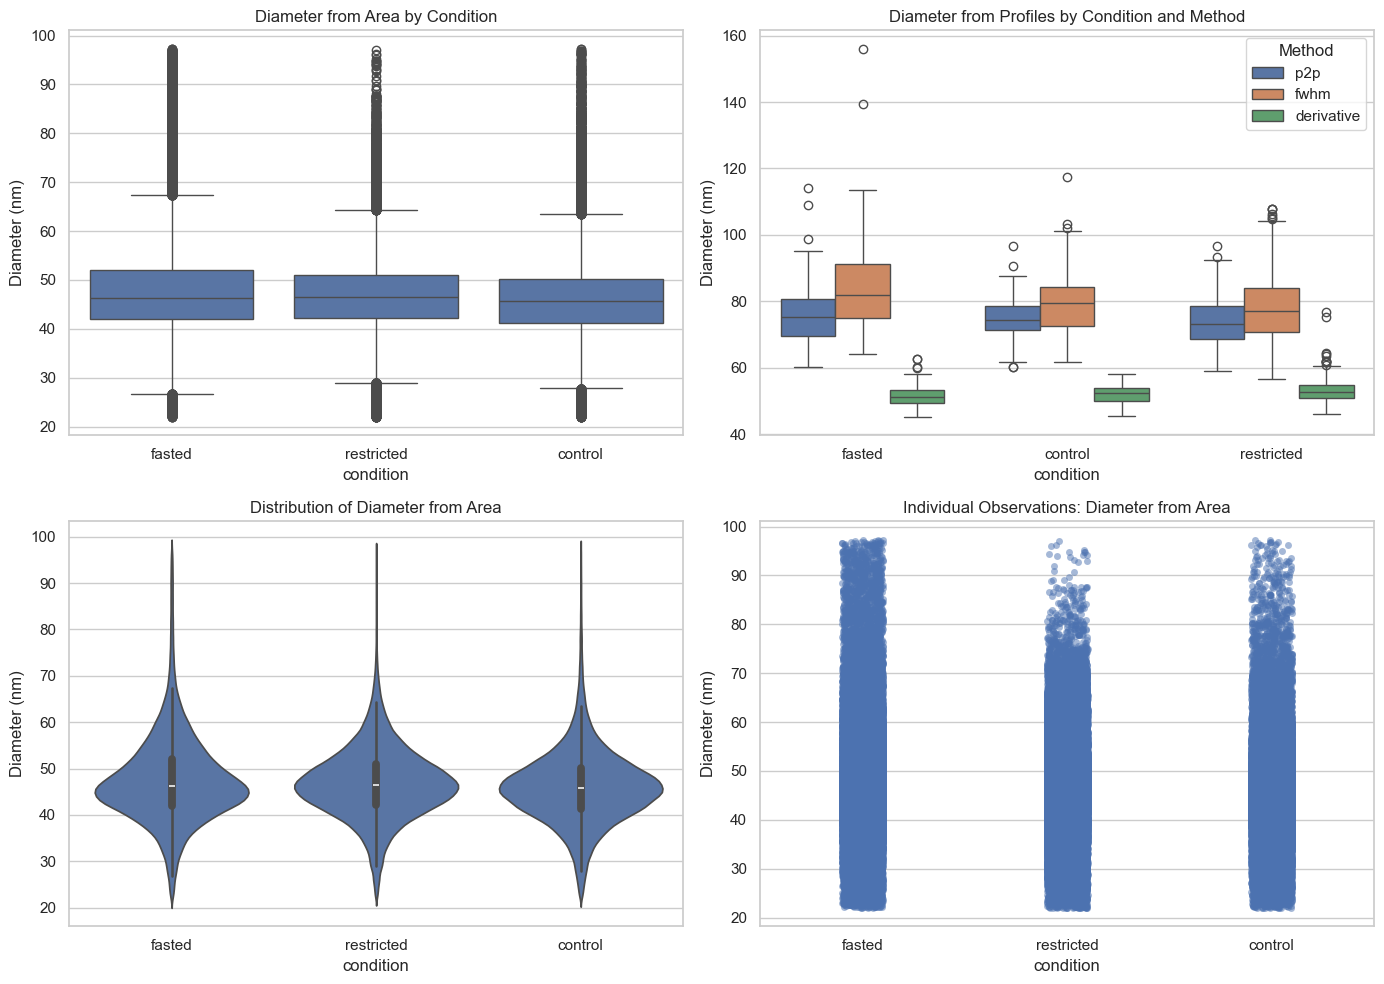

Visualization complete


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Diameter area by condition
sns.boxplot(data=diameter_area_df, x='condition', y='diameter_area', ax=axes[0, 0])
axes[0, 0].set_title('Diameter from Area by Condition')
axes[0, 0].set_ylabel('Diameter (nm)')

# Diameter profile by condition and method
sns.boxplot(data=diameter_profile_df, x='condition', y='diameter_nm', hue='method', ax=axes[0, 1])
axes[0, 1].set_title('Diameter from Profiles by Condition and Method')
axes[0, 1].set_ylabel('Diameter (nm)')
axes[0, 1].legend(title='Method', loc='upper right')

# Violin plot for area
sns.violinplot(data=diameter_area_df, x='condition', y='diameter_area', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Diameter from Area')
axes[1, 0].set_ylabel('Diameter (nm)')

# Strip plot with jitter
sns.stripplot(data=diameter_area_df, x='condition', y='diameter_area', 
              jitter=True, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Individual Observations: Diameter from Area')
axes[1, 1].set_ylabel('Diameter (nm)')

plt.tight_layout()
plt.show()

print("Visualization complete")

In [14]:
# Create summary statistics table
summary_area = diameter_area_df.groupby('condition')['diameter_area'].agg([
    ('n', 'count'),
    ('Mean', 'mean'),
    ('SD', 'std'),
    ('Min', 'min'),
    ('Median', 'median'),
    ('Max', 'max')
]).round(2)

print("\nDiameter Area - Summary Statistics:")
print(summary_area)

# Summary for profile diameters
summary_profile = diameter_profile_df.groupby(['method', 'condition'])['diameter_nm'].agg([
    ('n', 'count'),
    ('Mean', 'mean'),
    ('SD', 'std'),
    ('Min', 'min'),
    ('Median', 'median'),
    ('Max', 'max')
]).round(2)

print("\nDiameter Profile - Summary Statistics:")
print(summary_profile)

# Save to CSV
output_dir = Path("C:/Users/sthui4072/Github/fenestrations/results")
output_dir.mkdir(exist_ok=True)

summary_area.to_csv(output_dir / "diameter_area_summary.csv")
summary_profile.to_csv(output_dir / "diameter_profile_summary.csv")
diameter_area_df.to_csv(output_dir / "diameter_area_analysis.csv", index=False)
diameter_profile_df.to_csv(output_dir / "diameter_profile_analysis.csv", index=False)

print(f"\nResults saved to {output_dir}")


Diameter Area - Summary Statistics:
                 n   Mean    SD    Min  Median    Max
condition                                            
control      59363  46.05  8.25  22.03   45.70  97.29
fasted       65275  47.60  9.63  22.04   46.30  97.26
restricted  110227  46.79  7.76  22.00   46.54  97.12

Diameter Profile - Summary Statistics:
                         n   Mean     SD    Min  Median     Max
method     condition                                           
derivative control     137  52.11   2.73  45.39   52.28   58.14
           fasted      138  51.51   3.27  45.18   51.22   62.62
           restricted  273  53.24   3.89  46.06   52.58   76.78
fwhm       control     137  79.11   9.41  61.85   79.45  117.38
           fasted      138  84.43  13.64  64.01   81.85  156.03
           restricted  273  78.31  10.79  56.47   77.03  107.91
p2p        control     137  74.68   6.16  60.07   74.43   96.70
           fasted      138  76.43   9.06  60.16   75.37  113.98
           re

## Model Details

### Linear Mixed Effects Model Specification

**Diameter from Area:**
```
diameter_area ~ C(condition) + (1 | animal_id) + (1 | animal_id:stub)
```

**Diameter from Derivative Method:**
```
diameter_nm ~ C(condition) + (1 | animal_id)
```

### Interpretation

- **Fixed effects**: Condition (control, fasted, protein restricted) coefficients show mean differences relative to the reference level
- **Random intercepts**:
  - `animal_id` captures between-animal variability
  - `animal_id:stub` captures additional within-animal, between-stub variability
- **REML estimation**: Restricted maximum likelihood for unbiased variance estimates
- **Model summary**: Provides parameter estimates (fixed effects), standard errors, t-values, and p-values for individual parameters
- **NOTE**: ROIs are not independent (clustered within stubs and animals), so overall significance tests (ANOVA/LRT) are not appropriate. Instead, interpret individual parameter estimates and their confidence intervals from the model summary.

### Output Files

- `diameter_area_summary.csv`: Descriptive statistics for area-based diameter
- `diameter_profile_summary.csv`: Descriptive statistics for profile-based diameter
- `diameter_area_analysis.csv`: Full analysis data for diameter from area
- `diameter_profile_analysis.csv`: Full analysis data for diameter from profiles